# Prep: IndoBERT fine-tuning for news sentiment (GEMASTIK 2022 data)

Fine-tunes `ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa` with a Keras head on title + content to predict `sentimen_berita`.

In [ ]:
DATA_DIR = "../data"

## Import Library

In [2]:
import pandas as pd
import numpy as np

from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, TFBertModel, TrainingArguments, Trainer, \
    AutoModelForSequenceClassification, EarlyStoppingCallback
# import evaluate
import torch
import tensorflow as tf
import keras.backend as K
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Input, Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, recall_score, precision_score

In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
print(torch.cuda.is_available())

False


In [5]:
df = pd.read_csv(f"{DATA_DIR}/gemastik_22.csv")
df.head()

,id,sumber,kodekat,kodesubkat,kategori,subkategori,katakunci,tanggal,judul_berita,konten_berita,nama_tokoh,jabatan,organisasi,lokasi,alias,kutipan,sentimen_kutipan,sentimen_berita
0,568576e9e95,Detik,Q,Q,Jasa Kesehatan dan Kegiatan Sosial Swasta,Jasa Kesehatan dan Kegiatan Sosial Swasta,Jumlah pasien,2021-06-17,"BOR Sudah 89 Persen, RSUD Soreang Bandung Siap...",Bandung -\n\nSatuan Tugas Penanganan COVID-19 ...,[],['Bupati Bandung'],"['Bed Occupancy Ratio (BOR)', 'Pemda', 'BOR']","['Bandung', 'Kabupaten Bandung', 'Kota Bandung']",[],"['mengatakan, telah mengadakan rapat dan memut...",Netral,Netral
1,80f931fe95e,Detik,D,D2,Pengadaan Listrik dan Gas,Pengadaan Gas dan Produksi Es,Jaringan Gas,2021-03-18,"Honda CB650R Indonesia Dapat Penyegaran, Harga...",Jakarta -\n\nAstra Honda Motor (AHM) resmi men...,"['Biasa Mejeng', 'Resmi Dijual']",[],"['Big', 'LED']","['Jakarta', 'Indonesia']",[],"['""Rasa bangga itu menyempurnakan gaya hidup m...",Positif,Positif
2,1bd2af6ef23,Antara,C,C8,Industri Pengolahan,"Industri Kimia, Farmasi dan Obat Tradisional",farmasi,2021-02-23,Vaksin COVID-19 Pfizer disetujui satu dari tig...,Seoul (ANTARA) - Panel ahli pertama dari tiga ...,['Mulyo Sunyoto'],[],"['Universitas Oxford', 'BioNTech']","['Korea Selatan', 'Amerika Serikat', 'Korsel',...",['¬©'],[],Netral,Positif
3,ac2b55af24c,Detik,A,A2,"Pertanian, Kehutanan, dan Perikanan",Kehutanan dan Penebangan Kayu,bambu,2021-01-26,"TPU Srengseng Sawah Penuh, DKI Rujuk Jenazah C...","Jakarta - TPU Srengseng Sawah, Jakarta Selatan...",['Ivan Nurcahyo'],[],"['Pemprov DKI', 'Dinas Pertamanan']","['Jakarta', 'Jakarta Selatan', 'DKI Jakarta', ...",[],"['""Kita sebutnya TPU Bambu Wulung, sebenarnya ...",Positif,Positif
4,3f50747a1d4,Antara,Q,Q,Jasa Kesehatan dan Kegiatan Sosial Swasta,Jasa Kesehatan dan Kegiatan Sosial Swasta,wabah penyakit,2021-05-04,Media Korea Utara sebut vaksin COVID-19 bukan ...,Seoul (ANTARA) - Media pemerintah Korea Utara ...,['Edwin Salvador'],[],['Partai Buruh'],"['Korea Utara', 'Korea Selatan', 'China', 'Kor...",['¬©'],['mengatakan wabah di sana tidak dapat dikesam...,Netral,Netral


In [6]:
df['judul_konten'] = df['judul_berita'] + ' ' + df['konten_berita']
df['judul_konten'].head()

0    BOR Sudah 89 Persen, RSUD Soreang Bandung Siap...
1    Honda CB650R Indonesia Dapat Penyegaran, Harga...
2    Vaksin COVID-19 Pfizer disetujui satu dari tig...
3    TPU Srengseng Sawah Penuh, DKI Rujuk Jenazah C...
4    Media Korea Utara sebut vaksin COVID-19 bukan ...
Name: judul_konten, dtype: object

In [7]:
# MODEL = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
MODEL = 'ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa'

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL)

In [9]:
df['judul_konten'].tolist()[:5]

['BOR Sudah 89 Persen, RSUD Soreang Bandung Siapkan 100 Kasur Bandung -\n\nSatuan Tugas Penanganan COVID-19 Kabupaten Bandung memutuskan akan menggunakan RSUD Soreang menjadi lokasi penanganan pasien COVID-19. Sebanyak 100 kasur akan disiapkan di RSUD Soreang.\n\nSebelumnya, Kabupaten Bandung masuk dalam zona risiko tinggi atau zona merah. Per tanggal 16 Juni 2021, Bed Occupancy Ratio (BOR) atau keterisian ruang isolasi mencapai 89 persen.\n\nHal tersebut diungkapkan oleh Bupati Bandung Dadang Supriatna. Ia mengatakan, telah mengadakan rapat dan memutuskan untuk menggunakan RSUD Soreang dijadikan rumah sakit rujukan bagi pasien COVID-19.\n\n"Kita sudah instruksikan dan rapat evaluasi untuk bed, karena RSUD Soreang lama sudah ada pemindahan dan ijin sudah hampir selesai. Maka kami sudah sepakat akan menambah 100 bed isolasi dalam membantu masyarakat," ujar Bupati Bandung Dadang Supriatna, di Komplek Pemda Bandung, Kamis (1762021).\n\nSelain di RSUD Soreang, sejumlah rumah sakit rujukan 

In [10]:
LABEL_MAP = {
    "Negatif": 0,
    "Netral": 1,
    "Positif": 2,
}

INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

X = df['judul_konten'].values
y = np.array(df["sentimen_berita"].map(LABEL_MAP))
print(X.shape, y.shape)
y[:10]

(5289,) (5289,)


array([1, 2, 2, 2, 1, 1, 2, 1, 2, 2], dtype=int64)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4231,), (1058,), (4231,), (1058,))

In [12]:
MAX_LENGTH = 64

tokenized_text_detail_train = tokenizer(
    text=X_train.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

tokenized_text_detail_test = tokenizer(
    text=X_test.tolist(),
    add_special_tokens=True,
    max_length=MAX_LENGTH,
    truncation=True,
    padding=True,
    return_tensors='tf',
    return_token_type_ids=False,
    return_attention_mask=True,
    verbose=True
)

tokenized_text_detail_train

{'input_ids': <tf.Tensor: shape=(4231, 64), dtype=int32, numpy=
array([[    3,  2337,  5373, ...,  9451,  1582,     1],
       [    3,  2338,  4019, ..., 25129,  9077,     1],
       [    3,    27, 20595, ...,  3370, 11467,     1],
       ...,
       [    3, 11725,  1016, ...,  3398,  1535,     1],
       [    3, 30250,  7680, ...,  1684,  9059,     1],
       [    3,  2063,  1007, ..., 15718,  1018,     1]])>, 'attention_mask': <tf.Tensor: shape=(4231, 64), dtype=int32, numpy=
array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])>}

In [13]:
token_ids_train = np.array(tokenized_text_detail_train["input_ids"])
token_masks_train = np.array(tokenized_text_detail_train["attention_mask"])
token_ids_test = np.array(tokenized_text_detail_test["input_ids"])
token_masks_test = np.array(tokenized_text_detail_test["attention_mask"])

token_ids_train.shape, token_masks_train.shape, token_ids_test.shape, token_masks_test.shape

((4231, 64), (4231, 64), (1058, 64), (1058, 64))

## Using Keras

In [14]:
bert_model = TFBertModel.from_pretrained(MODEL, from_pt=True)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['classifier.weight', 'bert.embeddings.position_ids', 'classifier.bias']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


In [15]:
def f1_score(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    return 2 * (precision * recall) / (precision + recall + K.epsilon())

In [16]:
weight_initializer = tf.keras.initializers.GlorotNormal(seed=42)

input_ids = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="input_ids")
input_mask = Input(shape=(MAX_LENGTH,), dtype=tf.int32, name="attention_mask")

embeddings = bert_model(input_ids, attention_mask=input_mask)[0]  # 0 = last hidden state, 1 = poller_output
out = tf.keras.layers.GlobalMaxPool1D()(embeddings)
out = Dense(128, activation='relu', kernel_initializer = weight_initializer)(out)
out = tf.keras.layers.Dropout(0.1)(out)
out = Dense(32, activation='relu', kernel_initializer = weight_initializer)(out)

y = Dense(3, activation='softmax', kernel_initializer=weight_initializer)(out)

model = tf.keras.Model(inputs=[input_ids, input_mask], outputs=y)
model.layers[2].trainable = True

optimizer = Adam(
    learning_rate=5e-05,  # HF recommendation
    epsilon=1e-08,
    decay=0.01,
    clipnorm=1.0
)
loss = CategoricalCrossentropy()
metric = f1_score
# metric = CategoricalAccuracy('balanced_accuracy')

model.compile(
    optimizer=optimizer,
    # loss=loss,
    loss="categorical_crossentropy",
    metrics=metric
)

with tf.device('/device:GPU:0'):
    history = model.fit(
        x={'input_ids': token_ids_train, 'attention_mask': token_masks_train},
        y=to_categorical(y_train),
        validation_data=({'input_ids': token_ids_test, 'attention_mask': token_masks_test},
                         to_categorical(y_test)),
        epochs=10,
        batch_size=8
    )

Epoch 1/10
529/529 [==============================] - 80s 122ms/step - loss: 0.9407 - f1_score: 0.4838 - val_loss: 0.9515 - val_f1_score: 0.5095
Epoch 2/10
529/529 [==============================] - 63s 119ms/step - loss: 0.8118 - f1_score: 0.5675 - val_loss: 0.9461 - val_f1_score: 0.5666
Epoch 3/10
529/529 [==============================] - 62s 118ms/step - loss: 0.7107 - f1_score: 0.6705 - val_loss: 0.9800 - val_f1_score: 0.5730
Epoch 4/10
529/529 [==============================] - 68s 130ms/step - loss: 0.5925 - f1_score: 0.7499 - val_loss: 1.0235 - val_f1_score: 0.5753
Epoch 5/10
529/529 [==============================] - 65s 123ms/step - loss: 0.4895 - f1_score: 0.8050 - val_loss: 1.1229 - val_f1_score: 0.5761
Epoch 6/10
529/529 [==============================] - 66s 124ms/step - loss: 0.4221 - f1_score: 0.8408 - val_loss: 1.2254 - val_f1_score: 0.5908
Epoch 7/10
529/529 [==============================] - 65s 123ms/step - loss: 0.3612 - f1_score: 0.8688 - val_loss: 1.2916 - val_f1

In [17]:
start = 0

import matplotlib.pyplot as plt

def plot_loss(history_dict):
    key1 = list(history_dict.keys())[0]
    key2 = list(history_dict.keys())[2]
    loss_values = history_dict[key1][start:]
    val_loss_values = history_dict[key2][start:]
    plt.plot(loss_values, "b-", label=key1)
    plt.plot(val_loss_values, "r--", label=key2)
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()
    print(key1, ": ", history_dict[key1][-1], key2, ": ", history_dict[key2][-1])


def plot_metric(history_dict):
    key1 = list(history_dict.keys())[1]
    key2 = list(history_dict.keys())[3]
    metric_values = history_dict[key1][start:]
    val_metric_values = history_dict[key2][start:]
    plt.plot(metric_values, "b-", label=key1)
    plt.plot(val_metric_values, "r--", label=key2)
    plt.title("Training vs Validation Metric")
    plt.legend()
    plt.show()
    print(key1, ": ", history_dict[key1][-1], key2, ": ", history_dict[key2][-1])

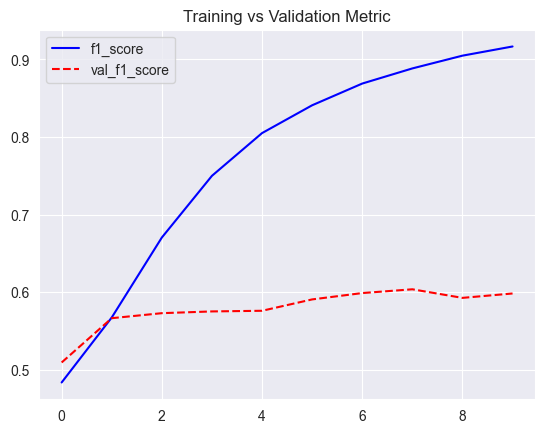

f1_score :  0.9165245294570923 val_f1_score :  0.5983977317810059


In [19]:
plot_metric(history.history)

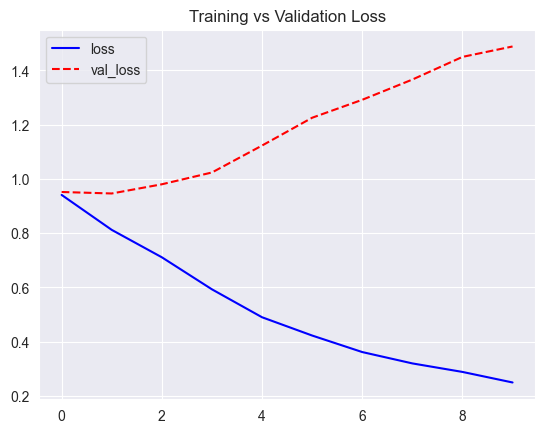

loss :  0.24894963204860687 val_loss :  1.4882516860961914


In [20]:
plot_loss(history.history)

In [21]:
predicted = model.predict({'input_ids': token_ids_test, 'attention_mask': token_masks_test})
y_predicted = np.argmax(predicted, axis=1)
print(classification_report(y_test, y_predicted))

34/34 [==============================] - 5s 77ms/step
              precision    recall  f1-score   support

           0       0.50      0.40      0.45       173
           1       0.46      0.52      0.49       337
           2       0.72      0.71      0.71       548

    accuracy                           0.60      1058
   macro avg       0.56      0.54      0.55      1058
weighted avg       0.60      0.60      0.60      1058


In [21]:
torch.cuda.empty_cache()

In [91]:
!pip install  -q numba

In [15]:
from numba import cuda

device = cuda.get_current_device()
device.reset()